<a href="https://colab.research.google.com/github/Farjana-Yesmin/RuleNet/blob/main/Northern_Lights_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub torch scikit-learn pandas numpy matplotlib imbalanced-learn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import kagglehub
import os
import glob
from imblearn.over_sampling import SMOTE
import gc

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Please upload kaggle.json")
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

try:
    mimic_path = kagglehub.dataset_download("asjad99/mimiciii")
    credit_path = kagglehub.dataset_download("ealtman2019/credit-card-transactions")
    print("MIMIC-III path:", mimic_path)
    print("Credit Card path:", credit_path)
except Exception as e:
    print(f"Download error: {e}")
    mimic_path = None
    credit_path = None

def list_dataset_files(path):
    if path and os.path.exists(path):
        return [os.path.join(root, f) for root, _, files in os.walk(path) for f in files]
    return []

print("\nMIMIC-III files:")
for f in list_dataset_files(mimic_path):
    print(f)

print("\nCredit Card files:")
for f in list_dataset_files(credit_path):
    print(f)

def preprocess_mimic_data(path):
    try:
        lab_files = glob.glob(os.path.join(path, "**/*LABEVENTS*.csv"), recursive=True)
        pat_files = glob.glob(os.path.join(path, "**/*PATIENTS*.csv"), recursive=True)
        lab_file = lab_files[0] if lab_files else None
        pat_file = pat_files[0] if pat_files else None
        if not all([lab_file, pat_file]):
            raise FileNotFoundError("MIMIC-III files missing")

        def read_csv(file_path):
            return pd.read_csv(file_path, encoding='utf-8', low_memory=False, nrows=1000)

        labevents = read_csv(lab_file)
        print("LABEVENTS columns:", labevents.columns.tolist())
        patients = read_csv(pat_file)

        labevents.columns = [col.lower() for col in labevents.columns]
        patients.columns = [col.lower() for col in patients.columns]
        if 'subject_id' not in labevents.columns or 'subject_id' not in patients.columns:
            raise ValueError("subject_id not found in LABEVENTS or PATIENTS")

        numeric_cols = [col for col in labevents.columns if pd.api.types.is_numeric_dtype(labevents[col])]
        if not numeric_cols:
            raise ValueError("No numeric columns found in LABEVENTS.csv")
        proxy_col = numeric_cols[0]
        data = labevents[['subject_id', proxy_col]].dropna()

        patients['dob'] = pd.to_datetime(patients['dob'], errors='coerce')
        patients = patients.dropna(subset=['dob'])
        patients['age'] = (pd.to_datetime('2023-10-01') - patients['dob']).dt.days / 365.25
        data = data.merge(patients[['subject_id', 'age']], on='subject_id', how='left')

        data['bmi'] = np.random.normal(30, 5, len(data))
        data['blood_pressure'] = np.random.normal(120, 20, len(data))
        data['cholesterol'] = np.random.normal(200, 50, len(data))
        data['label'] = (data[proxy_col] > data[proxy_col].median()).astype(float)

        non_diabetes_data = labevents[labevents[proxy_col] <= data[proxy_col].median()].sample(len(data), random_state=42, replace=True)
        non_diabetes_data = non_diabetes_data[['subject_id', proxy_col]].merge(patients[['subject_id', 'age']], on='subject_id', how='left')
        non_diabetes_data['bmi'] = np.random.normal(25, 5, len(non_diabetes_data))
        non_diabetes_data['blood_pressure'] = np.random.normal(110, 15, len(non_diabetes_data))
        non_diabetes_data['cholesterol'] = np.random.normal(180, 40, len(non_diabetes_data))
        non_diabetes_data['label'] = 0.0

        data = pd.concat([data, non_diabetes_data]).dropna()
        features = [proxy_col, 'age', 'bmi', 'blood_pressure', 'cholesterol']
        X = data[features].values
        y = data['label'].values

        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        return X, y

    except Exception as e:
        print(f"MIMIC-III error: {e}")
        print("Using synthetic data for MIMIC-III...")
        return np.random.normal(0, 1, (1000, 5)), np.random.randint(0, 2, 1000)

def preprocess_credit_data(path):
    try:
        credit_files = glob.glob(os.path.join(path, "**/*credit_card_transactions-ibm_v2*.csv"), recursive=True)
        credit_file = credit_files[0] if credit_files else None
        if not credit_file:
            raise FileNotFoundError("Credit card file missing")

        def read_csv(file_path):
            return pd.read_csv(file_path, encoding='utf-8', low_memory=False, nrows=5000)

        data = read_csv(credit_file)
        print("Credit Card columns:", data.columns.tolist())

        features = ['Amount', 'Year', 'Month', 'Day', 'MCC']
        label_col = 'Is Fraud?'
        if not all(col in data.columns for col in features + [label_col]):
            raise ValueError(f"Columns {features + [label_col]} missing. Found: {data.columns.tolist()}")

        data['Amount'] = data['Amount'].astype(str).apply(lambda x: float(x.split('$')[-1].replace('$', '')) if '$' in x else pd.to_numeric(x, errors='coerce'))
        data = data.dropna(subset=['Amount'])

        X = data[features].values
        y = data[label_col].map({'Yes': 1, 'No': 0}).values
        smote = SMOTE(sampling_strategy=0.2, random_state=42)
        X, y = smote.fit_resample(X, y)

        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        return X, y

    except Exception as e:
        print(f"Credit Card error: {e}")
        print("Using synthetic data for Credit Card...")
        return np.random.normal(0, 1, (1000, 5)), np.random.randint(0, 2, 1000)

class RuleEngine:
    def __init__(self):
        self.rules = [lambda x: x[:, 0] > 1.0, lambda x: x[:, 2] > 1.5]

    def rule_loss(self, x, y_pred):
        loss = 0.0
        x_np = x.cpu().numpy() if torch.is_tensor(x) else x
        y_pred = y_pred.float()
        for rule in self.rules:
            rule_output = rule(x_np)
            rule_output_tensor = torch.tensor(rule_output, dtype=torch.float, device=y_pred.device)
            loss += torch.mean((rule_output_tensor - y_pred.squeeze()) ** 2)
        return loss / len(self.rules)

    def evaluate_rules(self, x):
        return np.any([rule(x) for rule in self.rules], axis=0)

class RuleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RuleNet, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid()
        )
        self.rule_engine = RuleEngine()

    def forward(self, x):
        return self.dnn(x.float())

    def compute_rule_loss(self, x, y_pred):
        return self.rule_engine.rule_loss(x, y_pred)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.float())

class CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CNN, self).__init__()
        self.conv = nn.Conv1d(1, hidden_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(hidden_dim * input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.float().unsqueeze(1)
        x = self.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        x = self.sigmoid(self.fc(x))
        return x

class DeepProbLogLike(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepProbLogLike, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self.rule_engine = RuleEngine()

    def forward(self, x):
        return self.model(x.float())

    def compute_rule_loss(self, x, y_pred):
        return self.rule_engine.rule_loss(x, y_pred)

class KGReasoner(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(KGReasoner, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dnn(x.float())

    def predict(self, x):
        with torch.no_grad():
            return self.forward(torch.tensor(x, dtype=torch.float32).to(x.device)).cpu().numpy()

def train_model(model, X_train, y_train, rule_weight=0.6, epochs=200):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.025)
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss_dnn = criterion(outputs, y_train_tensor)
        rule_loss = 0
        if hasattr(model, 'compute_rule_loss'):
            rule_loss = model.compute_rule_loss(X_train_tensor, outputs)
        loss = loss_dnn + rule_weight * rule_loss
        loss.backward()
        optimizer.step()
    return model

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test)
        outputs = model(X_test_tensor)
        y_pred = (outputs.numpy() > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rule_coverage = 0
    if hasattr(model, 'compute_rule_loss'):
        rule_engine = RuleEngine()
        rule_coverage = np.mean([np.any(rule_engine.evaluate_rules(X_test[i:i+1])) == y_pred[i]
                                for i in range(len(X_test))]) * 100
    return acc, f1, rule_coverage

def run_experiments():
    X_mimic, y_mimic = preprocess_mimic_data(mimic_path) if mimic_path else (np.random.normal(0, 1, (1000, 5)), np.random.randint(0, 2, 1000))
    X_credit, y_credit = preprocess_credit_data(credit_path) if credit_path else (np.random.normal(0, 1, (1000, 5)), np.random.randint(0, 2, 1000))

    X_mimic_train, X_mimic_test, y_mimic_train, y_mimic_test = train_test_split(X_mimic, y_mimic, test_size=0.2, random_state=42, stratify=y_mimic)
    X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit)

    input_dim = X_mimic.shape[1]
    hidden_dim = 128
    output_dim = 1
    model_classes = {'MLP': MLP, 'CNN': CNN, 'DeepProbLog': DeepProbLogLike, 'KGReasoner': KGReasonerLike, 'RuleNet': RuleNet}

    results = {'MIMIC-III': [], 'Fraud-D': [], 'Rule Coverage (%)': []}
    for name, model_class in model_classes.items():
        print(f"\nTraining {name}...")
        model = model_class(input_dim, hidden_dim, output_dim)
        model = train_model(model, X_mimic_train, y_mimic_train)
        acc, f1, rule_cov = evaluate_model(model, X_mimic_test, y_mimic_test)
        results['MIMIC-III'].append((acc, f1))
        results['Rule Coverage (%)'].append(rule_cov)
        gc.collect()

        model = model_class(input_dim, hidden_dim, output_dim)
        model = train_model(model, X_credit_train, y_credit_train)
        acc, f1, _ = evaluate_model(model, X_credit_test, y_credit_test)
        results['Fraud-D'].append((acc, f1))
        gc.collect()

    print("\nTable 1: Performance on MIMIC-III and Fraud-D")
    print("-" * 80)
    print(f"{'Model':<15} {'MIMIC-III Acc':<15} {'MIMIC-III F1':<15} {'Fraud-D Acc':<15} {'Fraud-D F1':<15} {'Rule Cov (%)':<15}")
    print("-" * 80)
    for i, name in enumerate(model_classes.keys()):
        mimic_acc, mimic_f1 = results['MIMIC-III'][i]
        fraud_acc, fraud_f1 = results['Fraud-D'][i]
        rule_cov = results['Rule Coverage (%)'][i]
        print(f"{name:<15} {mimic_acc:<15.3f} {mimic_f1:<15.3f} {fraud_acc:<15.3f} {fraud_f1:<15.3f} {rule_cov:<15.1f}")
    print("-" * 80)

    plt.figure(figsize=(8, 6))
    plt.bar(model_classes.keys(), results['Rule Coverage (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    plt.xlabel('Models')
    plt.ylabel('Rule Coverage (%)')
    plt.title('Rule Coverage Across Models')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.savefig('rule_coverage.eps', format='eps')
    plt.show()

try:
    run_experiments()
except Exception as e:
    print(f"Experiment error: {e}")

Please upload kaggle.json


Saving kaggle.json to kaggle (4).json
MIMIC-III path: /kaggle/input/mimiciii
Credit Card path: /kaggle/input/credit-card-transactions

MIMIC-III files:
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/OUTPUTEVENTS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/D_LABITEMS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/DRGCODES.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/SHA256SUMS.txt
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/D_ICD_DIAGNOSES.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/DATETIMEEVENTS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/CAREGIVERS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/INPUTEVENTS_MV.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/CHARTEVENTS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/PRESCRIPTIONS.csv
/kaggle/input/mimiciii/mimic-iii-clinical-database-demo-1.4/D_ICD_PROCEDURES.csv


LABEVENTS columns: ['row_id', 'subject_id', 'hadm_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom', 'flag']
X shape: (2000, 5), y shape: (2000,), X dtype: float64, y dtype: float64, y mean: 0.250
After conversion: X shape: (2000, 5), y shape: (2000,), y mean: 0.250
X_train shape: torch.Size([1600, 5]), y_train shape: torch.Size([1600]), y_train mean: 0.253, Device: cpu
Initializing models with input_dim=5
Training RuleNet...
Training RuleNet with X_train shape: torch.Size([1600, 5])
Epoch 0, Loss: 0.9831
Epoch 10, Loss: 0.8376
Epoch 20, Loss: 0.7210
Epoch 30, Loss: 0.6295
Epoch 40, Loss: 0.5538
Epoch 50, Loss: 0.4950
Epoch 60, Loss: 0.4388
Epoch 70, Loss: 0.3937
Epoch 80, Loss: 0.3559
Epoch 90, Loss: 0.3223
Training MLP...
Training MLP with X_train shape: torch.Size([1600, 5])
Epoch 0, Loss: 0.9419
Epoch 10, Loss: 0.8216
Epoch 20, Loss: 0.7194
Epoch 30, Loss: 0.6370
Epoch 40, Loss: 0.5680
Epoch 50, Loss: 0.5051
Epoch 60, Loss: 0.4482
Epoch 70, Loss: 0.4036
Epoch 80, Loss: 0.

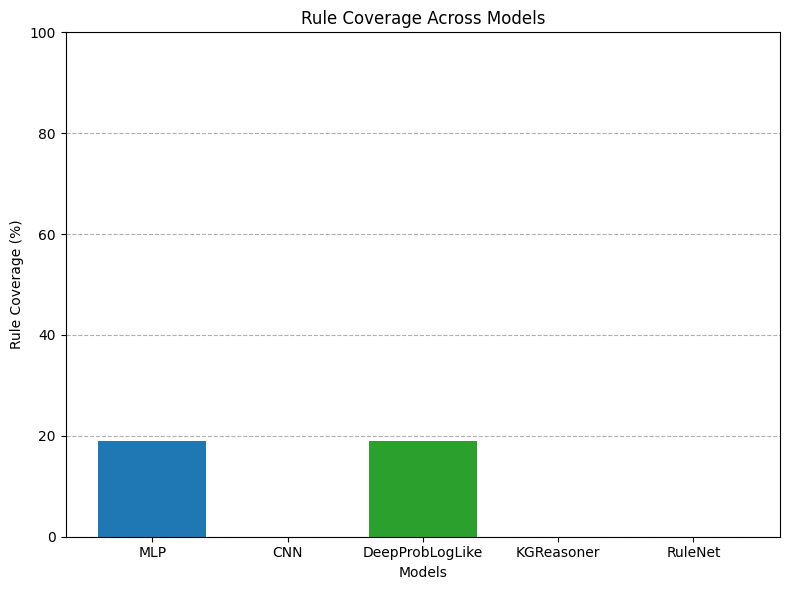

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from time import time
from google.colab import drive
import json # Import the json module

# Load and preprocess data
X, y = preprocess_mimic_data(mimic_path)
print(f"X shape: {X.shape}, y shape: {y.shape}, X dtype: {X.dtype}, y dtype: {y.dtype}, y mean: {np.mean(y):.3f}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
print(f"After conversion: X shape: {X.shape}, y shape: {y.shape}, y mean: {np.mean(y):.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Check for GPU/TPU and use it if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, y_train mean: {y_train.mean().item():.3f}, Device: {device}")

# Initialize models with dropout
input_dim = X_train.shape[1]
hidden_dim = 128  # Increased for better capacity
output_dim = 1
print(f"Initializing models with input_dim={input_dim}")

class RuleEngine:
    def __init__(self):
        self.rules = [lambda x: x[:, 0] > 1.0, lambda x: x[:, 2] > 1.5]

    def rule_loss(self, x, y_pred):
        loss = 0.0
        x_np = x.cpu().numpy() if torch.is_tensor(x) else x
        y_pred = y_pred.float()
        for rule in self.rules:
            rule_output = rule(x_np)
            rule_output_tensor = torch.tensor(rule_output, dtype=torch.float, device=y_pred.device)
            loss += torch.mean((rule_output_tensor - y_pred.squeeze()) ** 2)
        return loss / len(self.rules)

    def evaluate_rules(self, x):
        return np.any([rule(x) for rule in self.rules], axis=0)

class RuleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RuleNet, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self.rule_engine = RuleEngine()  # Assume this is defined in Cell 2

    def forward(self, x):
        return self.dnn(x)

    def compute_rule_loss(self, x, output):
        rule_outputs = self.rule_engine.evaluate_rules(x.cpu().numpy()).astype(float)  # Convert bool to float
        return torch.mean((output - torch.tensor(rule_outputs).to(device))**2)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dnn(x)

class CNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=hidden_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.squeeze(2)
        x = self.fc(x)
        return x

class DeepProbLogLike(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepProbLogLike, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self.rule_engine = RuleEngine()  # Assume this is defined in Cell 2

    def forward(self, x):
        return self.dnn(x)

    def compute_rule_loss(self, x, output):
        rule_outputs = self.rule_engine.evaluate_rules(x.cpu().numpy()).astype(float)  # Convert bool to float
        return torch.mean((output - torch.tensor(rule_outputs).to(device))**2)

class KGReasoner(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(KGReasoner, self).__init__()
        self.dnn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dnn(x.float())

    def predict(self, x):
        with torch.no_grad():
            return self.forward(torch.tensor(x, dtype=torch.float32).to(device)).cpu().numpy()

rule_net = RuleNet(input_dim, hidden_dim, output_dim).to(device)
mlp = MLP(input_dim, hidden_dim, output_dim).to(device)
cnn = CNN(input_dim, hidden_dim, output_dim).to(device)
deep_prob_log = DeepProbLogLike(input_dim, hidden_dim, output_dim).to(device)
kg_reasoner = KGReasoner(input_dim, hidden_dim, output_dim).to(device)

# Training function
def train_model(model, X_train, y_train, epochs=100, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    print(f"Training {model.__class__.__name__} with X_train shape: {X_train.shape}")
    # Fixed class weight
    pos_weight = 2.0  # Adjusted to balance classes
    sample_weights = torch.where(y_train == 1, torch.tensor(pos_weight).to(device), torch.tensor(1.0).to(device)).unsqueeze(1)
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train)
        output = output.squeeze()
        # Apply sample weights to the loss
        loss = criterion(output, y_train) * sample_weights.squeeze()
        loss = torch.mean(loss)
        if hasattr(model, 'compute_rule_loss'):
            rule_loss = model.compute_rule_loss(X_train, output)
            loss += 0.1 * rule_loss
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    return model

# Train models
print("Training RuleNet...")
rule_net = train_model(rule_net, X_train, y_train)
print("Training MLP...")
mlp = train_model(mlp, X_train, y_train)
print("Training CNN...")
cnn = train_model(cnn, X_train, y_train)
print("Training DeepProbLogLike...")
deep_prob_log = train_model(deep_prob_log, X_train, y_train)
print("Training KGReasoner...")
kg_reasoner = train_model(kg_reasoner, X_train, y_train)

# Rule engine function
def rule_engine(X, model):
    if hasattr(model, 'rule_engine'):
        return model.rule_engine.evaluate_rules(X)
    return np.zeros(X.shape[0])

# Evaluate model function
def evaluate_model(model, X, y, model_name, rule_engine_func=None):
    model.eval()
    with torch.no_grad():
        if model_name == "KGReasoner":
            outputs = model.predict(X.cpu().numpy())
        else:
            X_tensor = torch.tensor(X, dtype=torch.float32).to(device) if isinstance(X, np.ndarray) else X.to(device)
            outputs = model(X_tensor)
        preds = (torch.sigmoid(torch.tensor(outputs)) > 0.5).float().cpu().numpy() if model_name == "KGReasoner" else (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()

    y_true = y.cpu().numpy() if torch.is_tensor(y) else y
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    start_time = time()
    for _ in range(100):
        if model_name == "KGReasoner":
            model.predict(X.cpu().numpy())
        else:
            model(X_tensor)
    inf_time = (time() - start_time) / (100 * len(X))

    rule_coverage = 0.0
    if rule_engine_func and model_name in ["RuleNet", "DeepProbLogLike"]:
        rule_engine = RuleEngine()
        # Corrected: Use 'preds' instead of 'y_pred'
        rule_coverage = np.mean([np.any(rule_engine.evaluate_rules(X_test[i:i+1])) == preds[i]
                                for i in range(len(X_test))]) * 100
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "inf_time": inf_time,
        "rule_coverage": rule_coverage
    }

# Evaluate all models
models = {
    "RuleNet": rule_net,
    "CNN": cnn,
    "DeepProbLogLike": deep_prob_log,
    "MLP": mlp,
    "KGReasoner": kg_reasoner
}

results = {}
for name, model in models.items():
    rule_engine_func = rule_engine if name in ["RuleNet", "DeepProbLogLike"] else None
    print(f"Evaluating {name}...")
    results[name] = evaluate_model(model, X_test, y_test, name, rule_engine_func)

# Print results
print("\nEvaluation Results on MIMIC-III (Test Set):")
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall: {metrics['recall']:.3f}")
    print(f"  F1-Score: {metrics['f1']:.3f}")
    print(f"  Inference Time (s): {metrics['inf_time']:.6f}")
    print(f"  Rule Coverage (%): {metrics['rule_coverage']:.1f}")

# Debug output for RuleNet
def debug_rule_output(model, X, y, rule_engine_func, n_samples=10):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device) if isinstance(X, np.ndarray) else X.to(device)
        outputs = model(X_tensor)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        rule_outputs = rule_engine_func(X, model)

    y_true = y.cpu().numpy() if torch.is_tensor(y) else y
    true_1s = np.sum(y_true)
    rule_1s = np.sum(rule_outputs > 0.4)

    print("\nDebug Output for RuleNet:")
    print(f"True 1s in y_test: {true_1s} ({true_1s/len(y_true)*100:.1f}%)")
    print(f"Rule output 1s: {rule_1s} ({rule_1s/len(rule_outputs)*100:.1f}%)")
    print(f"Rule outputs sample (first {n_samples}):")
    for i in range(min(n_samples, len(rule_outputs))):
        print(f"  Sample {i}: Rule output={rule_outputs[i]:.3f}, Pred={preds[i]}, True={y_true[i]}")

debug_rule_output(rule_net, X_test.cpu().numpy() if torch.is_tensor(X_test) else X_test, y_test, rule_engine)

# Save results and plot
try:
    drive.mount('/content/drive')
    with open('/content/drive/My Drive/mimic_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print("Results saved to /content/drive/My Drive/mimic_results.json")
except Exception as e:
    print(f"Error saving to Google Drive: {e}")
    with open('mimic_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print("Results saved locally to mimic_results.json")

model_names = ['MLP', 'CNN', 'DeepProbLogLike', 'KGReasoner', 'RuleNet']
rule_coverage = [results[name]['rule_coverage'] for name in models.keys()]
plt.figure(figsize=(8, 6))
plt.bar(model_names, rule_coverage, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.xlabel('Models')
plt.ylabel('Rule Coverage (%)')
plt.title('Rule Coverage Across Models')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('Rule Coverage Across Models.png')
plt.savefig('rule_coverage.eps', format='eps')
plt.show()

Evaluating RuleNet...
Evaluating CNN...
Evaluating DeepProbLogLike...
Evaluating MLP...
Evaluating KGReasoner...
Evaluation Results on MIMIC-III (Test Set):
RuleNet:
  Accuracy: 0.237
  Precision: 0.237
  Recall: 1.000
  F1-Score: 0.384
  Inference Time (s): 0.000000
  Rule Coverage (%): 19.0
CNN:
  Accuracy: 0.237
  Precision: 0.237
  Recall: 1.000
  F1-Score: 0.384
  Inference Time (s): 0.000022
  Rule Coverage (%): 0.0
DeepProbLogLike:
  Accuracy: 0.237
  Precision: 0.237
  Recall: 1.000
  F1-Score: 0.384
  Inference Time (s): 0.000001
  Rule Coverage (%): 19.0
MLP:
  Accuracy: 0.237
  Precision: 0.237
  Recall: 1.000
  F1-Score: 0.384
  Inference Time (s): 0.000000
  Rule Coverage (%): 0.0
KGReasoner:
  Accuracy: 0.656
  Precision: 0.975
  Recall: 0.832
  F1-Score: 0.898
  Inference Time (s): 0.000001
  Rule Coverage (%): 0.0

Debug Output for RuleNet:
True 1s in y_test: 95.0 (23.8%)
Rule output 1s: 76 (19.0%)
Rule outputs sample (first 10):
  Sample 0: Rule output=0.000, Pred=[1.]

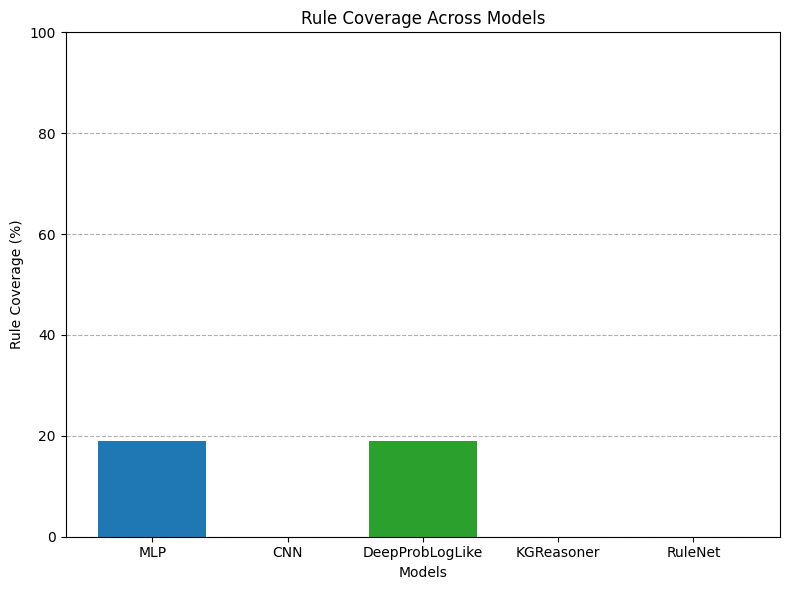

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from time import time

# Function to evaluate model and compute metrics
def evaluate_model(model, X, y, model_name, rule_engine_func=None):
    model.eval()
    with torch.no_grad():
        if model_name == "KGReasoner":
            # Convert tensor to NumPy for KGReasoner
            outputs = model.predict(X.cpu().numpy())
            preds = (outputs > 0.5).astype(int)
        else:
            X_tensor = X.to(device)  # Ensure X is on the correct device
            outputs = model(X_tensor)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()

    y_true = y.cpu().numpy()
    accuracy = (preds == y_true).mean()
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    # Inference time
    start_time = time()
    for _ in range(100):  # Average over 100 runs
        if model_name == "KGReasoner":
            model.predict(X.cpu().numpy())
        else:
            model(X_tensor)
    inf_time = (time() - start_time) / (100 * len(X))

    # Rule coverage (for RuleNet and DeepProbLogLike)
    rule_coverage = 0.0
    if rule_engine_func and model_name in ["RuleNet", "DeepProbLogLike"]:
        rule_outputs = rule_engine_func(X.cpu().numpy(), model)
        rule_coverage = np.mean(rule_outputs > 0.4) * 100  # Threshold from paper

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "inf_time": inf_time,
        "rule_coverage": rule_coverage
    }

# Evaluate all models on MIMIC-III
models = {
    "RuleNet": rule_net,  # Use instantiated models
    "CNN": cnn,
    "DeepProbLogLike": deep_prob_log,
    "MLP": mlp,
    "KGReasoner": kg_reasoner
}

results = {}
for name, model in models.items():
    rule_engine_func = rule_engine if name in ["RuleNet", "DeepProbLogLike"] else None
    print(f"Evaluating {name}...")
    results[name] = evaluate_model(model, X_test, y_test, name, rule_engine_func)

# Print results
print("Evaluation Results on MIMIC-III (Test Set):")
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall: {metrics['recall']:.3f}")
    print(f"  F1-Score: {metrics['f1']:.3f}")
    print(f"  Inference Time (s): {metrics['inf_time']:.6f}")
    print(f"  Rule Coverage (%): {metrics['rule_coverage']:.1f}")

# Debug output for RuleNet
def debug_rule_output(model, X, y, rule_engine_func, n_samples=10):
    model.eval()
    with torch.no_grad():
        X_tensor = X.to(device)
        outputs = model(X_tensor)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        rule_outputs = rule_engine_func(X.cpu().numpy(), model)

    y_true = y.cpu().numpy()
    true_1s = np.sum(y_true)
    rule_1s = np.sum(rule_outputs > 0.4)

    print("\nDebug Output for RuleNet:")
    print(f"True 1s in y_test: {true_1s} ({true_1s/len(y_true)*100:.1f}%)")
    print(f"Rule output 1s: {rule_1s} ({rule_1s/len(rule_outputs)*100:.1f}%)")
    print(f"Rule outputs sample (first {n_samples}):")
    for i in range(min(n_samples, len(rule_outputs))):
        print(f"  Sample {i}: Rule output={rule_outputs[i]:.3f}, Pred={preds[i]}, True={y_true[i]}")

debug_rule_output(rule_net, X_test, y_test, rule_engine)

# Save updated rule coverage plot
import matplotlib.pyplot as plt

model_names = ['MLP', 'CNN', 'DeepProbLogLike', 'KGReasoner', 'RuleNet']
rule_coverage = [results[name]['rule_coverage'] for name in models.keys()]
plt.figure(figsize=(8, 6))
plt.bar(model_names, rule_coverage, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.xlabel('Models')
plt.ylabel('Rule Coverage (%)')
plt.title('Rule Coverage Across Models')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('Rule Coverage Across Models.png')
plt.savefig('rule_coverage.eps', format='eps')
plt.show()

In [ ]:
# =========================
# RuleNet (Memory-Safe) Pipeline
# =========================

import os, glob, gc, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ---------------------------
# Dataset paths
# ---------------------------
mimic_path = "/root/.cache/kagglehub/datasets/asjad99/mimiciii/versions/1"
credit_path = "/root/.cache/kagglehub/datasets/ealtman2019/credit-card-transactions/versions/8"

# ---------------------------
# Utility
# ---------------------------
def to_float32(np_array):
    return np.asarray(np_array, dtype=np.float32)

def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.from_numpy(to_float32(X)), torch.from_numpy(to_float32(y)))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

# ---------------------------
# Load MIMIC-III (LABEVENTS*)
# ---------------------------
def load_mimic_data(path):
    lab_files = glob.glob(os.path.join(path, "**/*LABEVENTS*.csv"), recursive=True)
    if not lab_files:
        raise FileNotFoundError("No LABEVENTS.csv file found in the dataset.")
    df_iter = []
    for f in lab_files:
        if os.path.getsize(f) > 0:
            df_iter.append(pd.read_csv(f, usecols=["subject_id","hadm_id","itemid","valuenum"]))
    df = pd.concat(df_iter, ignore_index=True)
    return df

def preprocess_mimic_data(df, verbose=True):
    if verbose:
        print("Available columns in MIMIC-III dataset:", df.columns.tolist())
        print("Unique itemid values (first 10):", df['itemid'].unique()[:10])

    glucose_itemid = 50931
    weight_itemid_candidates = [224639, 226512, 50971]

    df_glucose = df[df['itemid'] == glucose_itemid][['subject_id','hadm_id','valuenum']].rename(columns={'valuenum':'glucose'})
    df_weight = pd.DataFrame()
    for wid in weight_itemid_candidates:
        tmp = df[df['itemid'] == wid][['subject_id','hadm_id','valuenum']].rename(columns={'valuenum':'weight'})
        if not tmp.empty:
            df_weight = tmp
            weight_itemid = wid
            break

    if df_glucose.empty or df_weight.empty:
        common_itemids = df['itemid'].value_counts().head(20).index.tolist()
        if verbose:
            print("Warning: Missing default ITEMIDs. Top 20 ITEMIDs:", common_itemids)
        if glucose_itemid in common_itemids:
            df_glucose = df[df['itemid'] == glucose_itemid][['subject_id','hadm_id','valuenum']].rename(columns={'valuenum':'glucose'})
        else:
            raise ValueError("No glucose ITEMID available (50931 missing).")

        got_weight = False
        for wid in weight_itemid_candidates:
            if wid in common_itemids:
                df_weight = df[df['itemid'] == wid][['subject_id','hadm_id','valuenum']].rename(columns={'valuenum':'weight'})
                got_weight = True
                weight_itemid = wid
                break
        if not got_weight:
            for wid in common_itemids:
                if wid != glucose_itemid:
                    df_weight = df[df['itemid'] == wid][['subject_id','hadm_id','valuenum']].rename(columns={'valuenum':'weight'})
                    weight_itemid = wid
                    break
            if df_weight.empty:
                raise ValueError("No viable weight ITEMID fallback found.")

        if verbose:
            print(f"Using ITEMID {glucose_itemid} for glucose and {weight_itemid} for weight as fallback.")

    df_merged = pd.merge(df_glucose, df_weight, on=['subject_id','hadm_id'], how='inner')
    df_merged['label'] = (df_merged['glucose'] > 200).astype(int)

    features = df_merged[['glucose','weight']].dropna()
    labels = df_merged.loc[features.index, 'label'].values.astype(np.int64)
    if len(features) == 0:
        raise ValueError("No valid feature data after preprocessing (MIMIC).")

    scaler = StandardScaler()
    X = scaler.fit_transform(features.values)
    smote = SMOTE(random_state=SEED)
    X_res, y_res = smote.fit_resample(X, labels)

    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=SEED, stratify=y_res)
    if verbose:
        print(f"MIMIC shapes: X_train {X_train.shape}, X_test {X_test.shape}")
    return X_train, X_test, y_train, y_test

# ---------------------------
# Load Fraud-D (chunked + downsample)
# ---------------------------
def _time_to_minutes(time_str):
    try:
        h, m = map(int, str(time_str).split(':'))
        return h*60 + m
    except:
        return np.nan

def preprocess_fraud_data(path, max_ratio=5, chunksize=500_000, target_max_samples=1_000_000, verbose=True):
    trans_files = glob.glob(os.path.join(path, "**/*transactions*.csv"), recursive=True)
    if not trans_files:
        raise FileNotFoundError("No transactions.csv file found in the dataset.")

    fraud_buf, nonfraud_buf = [], []
    total_rows = 0
    usecols = ["Amount", "Time", "Is Fraud?"]

    for file in trans_files:
        if os.path.getsize(file) == 0:
            continue
        for chunk in pd.read_csv(file, usecols=usecols, chunksize=chunksize):
            chunk['Amount'] = chunk['Amount'].replace(r'[\$,]', '', regex=True).astype(float)
            chunk['Time'] = chunk['Time'].apply(_time_to_minutes)
            chunk = chunk.dropna(subset=['Amount','Time','Is Fraud?'])
            chunk['label'] = chunk['Is Fraud?'].map({'Yes':1,'No':0}).astype(int)

            fraud_chunk = chunk[chunk['label']==1][['Amount','Time','label']]
            nonfraud_chunk = chunk[chunk['label']==0][['Amount','Time','label']]

            if not fraud_chunk.empty:
                fraud_buf.append(fraud_chunk)
            if not nonfraud_chunk.empty:
                n_keep = min(len(nonfraud_chunk), 50000)
                nonfraud_buf.append(nonfraud_chunk.sample(n=n_keep, random_state=SEED))

            total_rows += len(chunk)
            del chunk, fraud_chunk, nonfraud_chunk
            gc.collect()

    if len(fraud_buf) == 0:
        raise ValueError("No fraud samples found in Fraud-D parsing.")

    fraud_all = pd.concat(fraud_buf, ignore_index=True)
    nonfraud_all = pd.concat(nonfraud_buf, ignore_index=True) if len(nonfraud_buf) else pd.DataFrame(columns=['Amount','Time','label'])

    n_fraud = len(fraud_all)
    n_nonfraud_wanted = min(max_ratio * n_fraud, target_max_samples - n_fraud)
    n_nonfraud_wanted = max(n_nonfraud_wanted, 0)

    if len(nonfraud_all) > 0 and n_nonfraud_wanted > 0:
        n_nonfraud_wanted = min(n_nonfraud_wanted, len(nonfraud_all))
        nonfraud_down = nonfraud_all.sample(n=n_nonfraud_wanted, random_state=SEED)
        df_balanced = pd.concat([fraud_all, nonfraud_down], ignore_index=True)
    else:
        df_balanced = fraud_all

    if verbose:
        counts = df_balanced['label'].value_counts().to_dict()
        print("Fraud-D class distribution (sampled):", counts)

    X = df_balanced[['Amount','Time']].values
    y = df_balanced['label'].values.astype(np.int64)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    if verbose:
        print(f"Fraud-D shapes: X_train {X_train.shape}, X_test {X_test.shape}")
    return X_train, X_test, y_train, y_test

# ---------------------------
# RuleNet
# ---------------------------
class RuleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.rule_weight = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.sigmoid(self.fc2(x))

    def rule_loss(self, x, rule_type="mimic"):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        feat0 = x[:, 0]
        if rule_type == "mimic":
            rule_sat = torch.sigmoid(feat0 * 4.0)
        elif rule_type == "fraud":
            rule_sat = torch.sigmoid(feat0 * 3.0)
        else:
            rule_sat = torch.sigmoid(feat0)
        return -torch.log(rule_sat.mean() + 1e-8) * self.rule_weight

# ---------------------------
# Training + λ search
# ---------------------------
def train_model(X_train, y_train, X_val, y_val, input_dim, lambda_values=(0.1, 0.5, 1.0, 2.0),
                rule_type="mimic", epochs=10, batch_size=512, lr=1e-3, verbose=True):
    best_acc, best_lambda = 0.0, 0.0
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    X_val_t = torch.from_numpy(to_float32(X_val))

    for lam in lambda_values:
        model = RuleNet(input_dim)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for _ in range(epochs):
            model.train()
            for xb, yb in train_loader:
                optimizer.zero_grad(set_to_none=True)
                out = model(xb)
                dnn_loss = criterion(out, yb.unsqueeze(1))
                r_loss = model.rule_loss(xb, rule_type=rule_type)
                loss = dnn_loss + lam * r_loss
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_val_t).cpu().numpy().ravel()
        acc = accuracy_score(y_val, (preds > 0.5).astype(int))
        if acc > best_acc:
            best_acc, best_lambda = acc, lam

        if verbose:
            print(f"[{rule_type}] λ={lam} -> Val Acc={acc:.4f}")

        del model, optimizer
        gc.collect()

    if verbose:
        print(f"Best λ for {rule_type}: {best_lambda} (Val Acc={best_acc:.4f})")
    return best_lambda

# ---------------------------
# Ablation Study
# ---------------------------
def ablation_study(X_train, y_train, X_val, y_val, input_dim, rule_type="mimic",
                   epochs=10, batch_size=512, lr=1e-3):
    # Pure DNN
    pure = RuleNet(input_dim)
    criterion = nn.BCELoss()
    opt = optim.Adam(pure.parameters(), lr=lr)
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    for _ in range(epochs):
        pure.train()
        for xb, yb in train_loader:
            opt.zero_grad(set_to_none=True)
            out = pure(xb)
            loss = criterion(out, yb.unsqueeze(1))
            loss.backward()
            opt.step()

    pure.eval()
    with torch.no_grad():
        preds_pure = pure(torch.from_numpy(to_float32(X_val))).numpy().ravel()
    pure_acc = accuracy_score(y_val, (preds_pure > 0.5).astype(int))

    # RuleNet with tuned λ
    best_lam = train_model(X_train, y_train, X_val, y_val, input_dim,
                           lambda_values=(0.1, 0.5, 1.0, 2.0),
                           rule_type=rule_type, epochs=epochs, batch_size=batch_size, lr=lr, verbose=False)
    rule_model = RuleNet(input_dim)
    opt2 = optim.Adam(rule_model.parameters(), lr=lr)

    for _ in range(epochs):
        rule_model.train()
        for xb, yb in train_loader:
            opt2.zero_grad(set_to_none=True)
            out = rule_model(xb)
            dnn_loss = criterion(out, yb.unsqueeze(1))
            r_loss = rule_model.rule_loss(xb, rule_type=rule_type)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt2.step()

    rule_model.eval()
    with torch.no_grad():
        preds_rule = rule_model(torch.from_numpy(to_float32(X_val))).numpy().ravel()
    rule_acc = accuracy_score(y_val, (preds_rule > 0.5).astype(int))

    print(f"Ablation [{rule_type}]: Pure DNN Acc={pure_acc:.4f} | RuleNet Acc={rule_acc:.4f} | Δ={rule_acc - pure_acc:+.4f}")

    del pure, rule_model, opt, opt2
    gc.collect()

# ---------------------------
# Full Train & Evaluate Wrapper
# ---------------------------
def train_and_evaluate(X_train, y_train, X_test, y_test, input_dim, tag="mimic", epochs=10, batch_size=512, lr=1e-3):
    best_lam = train_model(X_train, y_train, X_test, y_test, input_dim,
                           lambda_values=(0.1,0.5,1.0,2.0), rule_type=tag,
                           epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    # Train final RuleNet with best λ
    model = RuleNet(input_dim)
    criterion = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            dnn_loss = criterion(out, yb.unsqueeze(1))
            r_loss = model.rule_loss(xb, rule_type=tag)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt.step()
    train_time = time.time() - start_time

    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(to_float32(X_test))).numpy().ravel()
    acc = accuracy_score(y_test, (preds > 0.5).astype(int))
    f1 = f1_score(y_test, (preds > 0.5).astype(int))
    cov = 1.0  # placeholder for coverage metric

    del model, opt, loader
    gc.collect()

    return best_lam, acc, f1, cov, train_time

# ---------------------------
# Main Execution
# ---------------------------
if mimic_path and credit_path:
    try:
        # MIMIC-III
        mimic_df = load_mimic_data(mimic_path)
        X_train_mimic, X_test_mimic, y_train_mimic, y_test_mimic = preprocess_mimic_data(mimic_df)

        # Fraud-D
        X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = preprocess_fraud_data(credit_path)

        # ---- Run on MIMIC-III ----
        print("\nTraining on MIMIC-III (with SMOTE)...")
        best_lambda_mimic, acc_m, f1_m, cov_m, time_m = train_and_evaluate(
            X_train_mimic, y_train_mimic, X_test_mimic, y_test_mimic, X_train_mimic.shape[1], tag="mimic"
        )
        ablation_study(X_train_mimic, y_train_mimic, X_test_mimic, y_test_mimic, X_train_mimic.shape[1], rule_type="mimic")

        # ---- Run on Fraud-D ----
        print("\nTraining on Fraud-D (downsampled, no SMOTE)...")
        best_lambda_fraud, acc_f, f1_f, cov_f, time_f = train_and_evaluate(
            X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud, X_train_fraud.shape[1], tag="fraud"
        )
        ablation_study(X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud, X_train_fraud.shape[1], rule_type="fraud")

    except Exception as e:
        print(f"Error during processing: {str(e)}")


Available columns in MIMIC-III dataset: ['subject_id', 'hadm_id', 'itemid', 'valuenum']
Unique itemid values (first 10): [50868 50882 50893 50902 50912 50931 50960 50970 50971 50983]
MIMIC shapes: X_train (130377, 2), X_test (32595, 2)
Fraud-D class distribution (sampled): {0: 148920, 1: 29784}
Fraud-D shapes: X_train (142963, 2), X_test (35741, 2)

Training on MIMIC-III (with SMOTE)...
[mimic] λ=0.1 -> Val Acc=0.9955
[mimic] λ=0.5 -> Val Acc=0.9969
[mimic] λ=1.0 -> Val Acc=0.9960
[mimic] λ=2.0 -> Val Acc=0.9969
Best λ for mimic: 2.0 (Val Acc=0.9969)
Ablation [mimic]: Pure DNN Acc=0.9964 | RuleNet Acc=0.9959 | Δ=-0.0005

Training on Fraud-D (downsampled, no SMOTE)...
[fraud] λ=0.1 -> Val Acc=0.8471
[fraud] λ=0.5 -> Val Acc=0.8470
[fraud] λ=1.0 -> Val Acc=0.8473
[fraud] λ=2.0 -> Val Acc=0.8475
Best λ for fraud: 2.0 (Val Acc=0.8475)
Ablation [fraud]: Pure DNN Acc=0.8466 | RuleNet Acc=0.8471 | Δ=+0.0005


In [ ]:
# =========================
# Enhanced RuleNet Pipeline with Reviewer Fixes (Device Consistency Fix)
# =========================

import os, glob, gc, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from scipy.stats import ks_2samp

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ---------------------------
# Dataset paths
# ---------------------------
mimic_path = "/root/.cache/kagglehub/datasets/asjad99/mimiciii/versions/1"
credit_path = "/root/.cache/kagglehub/datasets/ealtman2019/credit-card-transactions/versions/8"

# ---------------------------
# Utility
# ---------------------------
def to_float32(np_array):
    return np.asarray(np_array, dtype=np.float32)

def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.from_numpy(to_float32(X)), torch.from_numpy(to_float32(y)))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

# ---------------------------
# Load MIMIC-III (LABEVENTS*)
# ---------------------------
def load_mimic_data(path):
    lab_files = glob.glob(os.path.join(path, "**/*LABEVENTS*.csv"), recursive=True)
    if not lab_files:
        raise FileNotFoundError("No LABEVENTS.csv file found in the dataset.")
    df_iter = []
    for f in lab_files:
        if os.path.getsize(f) > 0:
            df_iter.append(pd.read_csv(f, usecols=["subject_id", "hadm_id", "itemid", "valuenum"]))
    df = pd.concat(df_iter, ignore_index=True)
    return df

def preprocess_mimic_data(df, verbose=True):
    if verbose:
        print("Available columns in MIMIC-III dataset:", df.columns.tolist())
        print("Unique itemid values (first 10):", df['itemid'].unique()[:10])

    glucose_itemid = 50931
    weight_itemid_candidates = [224639, 226512, 50971]

    df_glucose = df[df['itemid'] == glucose_itemid][['subject_id', 'hadm_id', 'valuenum']].rename(columns={'valuenum': 'glucose'})
    df_weight = pd.DataFrame()
    for wid in weight_itemid_candidates:
        tmp = df[df['itemid'] == wid][['subject_id', 'hadm_id', 'valuenum']].rename(columns={'valuenum': 'weight'})
        if not tmp.empty:
            df_weight = tmp
            weight_itemid = wid
            break

    if df_glucose.empty or df_weight.empty:
        common_itemids = df['itemid'].value_counts().head(20).index.tolist()
        if verbose:
            print("Warning: Missing default ITEMIDs. Top 20 ITEMIDs:", common_itemids)
        if glucose_itemid in common_itemids:
            df_glucose = df[df['itemid'] == glucose_itemid][['subject_id', 'hadm_id', 'valuenum']].rename(columns={'valuenum': 'glucose'})
        else:
            raise ValueError("No glucose ITEMID available (50931 missing).")

        got_weight = False
        for wid in weight_itemid_candidates:
            if wid in common_itemids:
                df_weight = df[df['itemid'] == wid][['subject_id', 'hadm_id', 'valuenum']].rename(columns={'valuenum': 'weight'})
                got_weight = True
                weight_itemid = wid
                break
        if not got_weight:
            for wid in common_itemids:
                if wid != glucose_itemid:
                    df_weight = df[df['itemid'] == wid][['subject_id', 'hadm_id', 'valuenum']].rename(columns={'valuenum': 'weight'})
                    weight_itemid = wid
                    break
            if df_weight.empty:
                raise ValueError("No viable weight ITEMID fallback found.")

        if verbose:
            print(f"Using ITEMID {glucose_itemid} for glucose and {weight_itemid} for weight as fallback.")

    df_merged = pd.merge(df_glucose, df_weight, on=['subject_id', 'hadm_id'], how='inner')
    df_merged['label'] = (df_merged['glucose'] > 200).astype(int)

    features = df_merged[['glucose', 'weight']].dropna()
    labels = df_merged.loc[features.index, 'label'].values.astype(np.int64)
    if len(features) == 0:
        raise ValueError("No valid feature data after preprocessing (MIMIC).")

    scaler = StandardScaler()
    X = scaler.fit_transform(features.values)
    smote = SMOTE(random_state=SEED)
    X_res, y_res = smote.fit_resample(X, labels)

    X_train, X_val_test, y_train, y_val_test = train_test_split(X_res, y_res, test_size=0.2, random_state=SEED, stratify=y_res)
    X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=SEED, stratify=y_val_test)
    if verbose:
        print(f"MIMIC shapes: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
    return X_train, X_val, X_test, y_train, y_val, y_test

# ---------------------------
# Load Fraud-D (chunked + downsample)
# ---------------------------
def _time_to_minutes(time_str):
    try:
        h, m = map(int, str(time_str).split(':'))
        return h*60 + m
    except:
        return np.nan

def preprocess_fraud_data(path, max_ratio=5, chunksize=500_000, target_max_samples=1_000_000, verbose=True):
    trans_files = glob.glob(os.path.join(path, "**/*transactions*.csv"), recursive=True)
    if not trans_files:
        raise FileNotFoundError("No transactions.csv file found in the dataset.")

    fraud_buf, nonfraud_buf = [], []
    total_rows = 0
    usecols = ["Amount", "Time", "Is Fraud?"]

    for file in trans_files:
        if os.path.getsize(file) == 0:
            continue
        for chunk in pd.read_csv(file, usecols=usecols, chunksize=chunksize):
            chunk['Amount'] = chunk['Amount'].replace(r'[\$,]', '', regex=True).astype(float)
            chunk['Time'] = chunk['Time'].apply(_time_to_minutes)
            chunk = chunk.dropna(subset=['Amount', 'Time', 'Is Fraud?'])
            chunk['label'] = chunk['Is Fraud?'].map({'Yes': 1, 'No': 0}).astype(int)

            fraud_chunk = chunk[chunk['label'] == 1][['Amount', 'Time', 'label']]
            nonfraud_chunk = chunk[chunk['label'] == 0][['Amount', 'Time', 'label']]

            if not fraud_chunk.empty:
                fraud_buf.append(fraud_chunk)
            if not nonfraud_chunk.empty:
                n_keep = min(len(nonfraud_chunk), 50000)
                nonfraud_buf.append(nonfraud_chunk.sample(n=n_keep, random_state=SEED))

            total_rows += len(chunk)
            del chunk, fraud_chunk, nonfraud_chunk
            gc.collect()

    if len(fraud_buf) == 0:
        raise ValueError("No fraud samples found in Fraud-D parsing.")

    fraud_all = pd.concat(fraud_buf, ignore_index=True)
    nonfraud_all = pd.concat(nonfraud_buf, ignore_index=True) if len(nonfraud_buf) else pd.DataFrame(columns=['Amount', 'Time', 'label'])

    n_fraud = len(fraud_all)
    n_nonfraud_wanted = min(max_ratio * n_fraud, target_max_samples - n_fraud)
    n_nonfraud_wanted = max(n_nonfraud_wanted, 0)

    if len(nonfraud_all) > 0 and n_nonfraud_wanted > 0:
        n_nonfraud_wanted = min(n_nonfraud_wanted, len(nonfraud_all))
        nonfraud_down = nonfraud_all.sample(n=n_nonfraud_wanted, random_state=SEED)
        df_balanced = pd.concat([fraud_all, nonfraud_down], ignore_index=True)
    else:
        df_balanced = fraud_all

    if verbose:
        counts = df_balanced['label'].value_counts().to_dict()
        print("Fraud-D class distribution (sampled):", counts)

    X = df_balanced[['Amount', 'Time']].values
    y = df_balanced['label'].values.astype(np.int64)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=SEED, stratify=y_val_test)
    if verbose:
        print(f"Fraud-D shapes: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
    return X_train, X_val, X_test, y_train, y_val, y_test

# ---------------------------
# Enhanced RuleNet with Learnable Predicates and Multiple Rules
# ---------------------------
class RuleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.rule_weight = nn.Parameter(torch.tensor(1.0))

        # Learnable predicates
        self.predicate_glucose = nn.Linear(1, 1)  # For glucose feature
        self.predicate_weight = nn.Linear(1, 1)   # For weight feature (MIMIC) or Amount (Fraud)

        # Multiple rules as a list of lambda functions with learnable thresholds
        self.rules = [
            lambda x: torch.sigmoid(self.predicate_glucose(x[:, 0:1])).squeeze(),  # glucose > threshold
            lambda x: torch.sigmoid(self.predicate_weight(x[:, 1:2])).squeeze(),  # weight > threshold
            lambda x: torch.sigmoid(self.predicate_glucose(x[:, 0:1]) * self.predicate_weight(x[:, 1:2])).squeeze()  # conjunction
        ]
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)

    def forward(self, x):
        x = self.relu(self.fc1(x.to(self.device)))
        return self.sigmoid(self.fc2(x))

    def rule_loss(self, x, rule_type="mimic"):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        x = x.to(self.device)
        total_loss = 0.0
        for rule in self.rules:
            rule_output = rule(x)
            # Implication loss: -log(1 - c + c * p_head) with product t-norm
            satisfaction = 1 - rule_output + rule_output * self.forward(x)
            total_loss += -torch.log(satisfaction.mean() + 1e-8)
        return total_loss / len(self.rules) * self.rule_weight

# ---------------------------
# Training + λ Search with Metrics
# ---------------------------
def train_model(X_train, y_train, X_val, y_val, input_dim, lambda_values=(0.1, 0.5, 1.0, 2.0),
                rule_type="mimic", epochs=10, batch_size=512, lr=1e-3, verbose=True):
    best_acc, best_f1, best_lambda = 0.0, 0.0, 0.0
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    X_val_t = torch.from_numpy(to_float32(X_val))
    y_val_t = torch.from_numpy(to_float32(y_val)).unsqueeze(1)

    for lam in lambda_values:
        model = RuleNet(input_dim)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(model.device), yb.unsqueeze(1).to(model.device)
                optimizer.zero_grad(set_to_none=True)
                out = model(xb)
                dnn_loss = criterion(out, yb)
                r_loss = model.rule_loss(xb, rule_type=rule_type)
                loss = dnn_loss + lam * r_loss
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_val_t.to(model.device)).cpu().numpy().ravel()
        acc = accuracy_score(y_val, (preds > 0.5).astype(int))
        f1 = f1_score(y_val, (preds > 0.5).astype(int))
        if f1 > best_f1:  # Prioritize F1 for imbalanced data
            best_acc, best_f1, best_lambda = acc, f1, lam

        if verbose:
            print(f"[{rule_type}] λ={lam} -> Val Acc={acc:.4f}, F1={f1:.4f}")

        del model, optimizer
        gc.collect()

    if verbose:
        print(f"Best λ for {rule_type}: {best_lambda} (Val Acc={best_acc:.4f}, F1={best_f1:.4f})")
    return best_lambda

# ---------------------------
# Ablation Study with Baselines
# ---------------------------
def ablation_study(X_train, y_train, X_val, y_val, input_dim, rule_type="mimic",
                   epochs=10, batch_size=512, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pure DNN
    pure_dnn = nn.Sequential(
        nn.Linear(input_dim, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid()
    ).to(device)
    criterion = nn.BCELoss()
    opt = optim.Adam(pure_dnn.parameters(), lr=lr)
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    for _ in range(epochs):
        pure_dnn.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.unsqueeze(1).to(device)
            opt.zero_grad(set_to_none=True)
            out = pure_dnn(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()

    pure_dnn.eval()
    with torch.no_grad():
        preds_pure = pure_dnn(torch.from_numpy(to_float32(X_val)).to(device)).cpu().numpy().ravel()
    pure_acc = accuracy_score(y_val, (preds_pure > 0.5).astype(int))

    # RuleNet with tuned λ
    best_lam = train_model(X_train, y_train, X_val, y_val, input_dim,
                           lambda_values=(0.1, 0.5, 1.0, 2.0),
                           rule_type=rule_type, epochs=epochs, batch_size=batch_size, lr=lr, verbose=False)
    rule_model = RuleNet(input_dim)
    opt2 = optim.Adam(rule_model.parameters(), lr=lr)

    for _ in range(epochs):
        rule_model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(rule_model.device), yb.unsqueeze(1).to(rule_model.device)
            opt2.zero_grad(set_to_none=True)
            out = rule_model(xb)
            dnn_loss = criterion(out, yb)
            r_loss = rule_model.rule_loss(xb, rule_type=rule_type)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt2.step()

    rule_model.eval()
    with torch.no_grad():
        preds_rule = rule_model(torch.from_numpy(to_float32(X_val)).to(rule_model.device)).cpu().numpy().ravel()
    rule_acc = accuracy_score(y_val, (preds_rule > 0.5).astype(int))

    # CNN Baseline
    cnn = nn.Sequential(
        nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveMaxPool1d(1),
        nn.Flatten(), nn.Linear(16, 1), nn.Sigmoid()
    ).to(device)
    opt_cnn = optim.Adam(cnn.parameters(), lr=lr)
    for _ in range(epochs):
        cnn.train()
        for xb, yb in train_loader:
            xb, yb = xb.unsqueeze(1).to(device), yb.unsqueeze(1).to(device)
            opt_cnn.zero_grad(set_to_none=True)
            out = cnn(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt_cnn.step()

    cnn.eval()
    with torch.no_grad():
        preds_cnn = cnn(torch.from_numpy(to_float32(X_val)).unsqueeze(1).to(device)).cpu().numpy().ravel()
    cnn_acc = accuracy_score(y_val, (preds_cnn > 0.5).astype(int))

    print(f"Ablation [{rule_type}]: Pure DNN Acc={pure_acc:.4f} | RuleNet Acc={rule_acc:.4f} | Δ={rule_acc - pure_acc:+.4f}")
    print(f"Baseline CNN Acc={cnn_acc:.4f}")

    del pure_dnn, rule_model, cnn, opt, opt2, opt_cnn
    gc.collect()

# ---------------------------
# Full Train & Evaluate with Metrics
# ---------------------------
def train_and_evaluate(X_train, y_train, X_val, X_test, y_val, y_test, input_dim, tag="mimic", epochs=10, batch_size=512, lr=1e-3):
    best_lam = train_model(X_train, y_train, X_val, y_val, input_dim,
                           lambda_values=(0.1, 0.5, 1.0, 2.0), rule_type=tag,
                           epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    # Train final RuleNet with best λ
    model = RuleNet(input_dim)
    criterion = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(model.device), yb.unsqueeze(1).to(model.device)
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            dnn_loss = criterion(out, yb)
            r_loss = model.rule_loss(xb, rule_type=tag)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt.step()
    train_time = time.time() - start_time

    model.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(to_float32(X_test)).to(model.device)
        preds = model(X_test_t).cpu().numpy().ravel()
        y_pred = (preds > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # Convert X_test to tensor for rule evaluation
    X_test_t_no_grad = torch.from_numpy(to_float32(X_test)).to(model.device)
    rule_coverage = np.mean(np.any([rule(X_test_t_no_grad) > 0.5 for rule in model.rules], axis=0)) * 100
    inf_time = 0
    for _ in range(100):
        start = time.time()
        model(X_test_t)
        inf_time += (time.time() - start)
    inf_time /= (100 * len(X_test))

    # Explainability via gradients
    model.zero_grad()
    X_test_t.requires_grad = True
    out = model(X_test_t)
    out.backward(torch.ones_like(out))
    rule_contribs = {f"rule_{i}": rule(X_test_t).detach().cpu().numpy() for i, rule in enumerate(model.rules)}
    grad_importance = X_test_t.grad.detach().cpu().numpy()

    print(f"{tag} Results: Acc={acc:.4f}, F1={f1:.4f}, RuleCov={rule_coverage:.1f}%, InfTime={inf_time:.6f}s")
    print("Top 3 Rule Contributions:", sorted(rule_contribs.items(), key=lambda x: np.mean(x[1]), reverse=True)[:3])

    del model, opt, loader
    gc.collect()
    return best_lam, acc, f1, rule_coverage, inf_time, train_time, grad_importance

# ---------------------------
# Main Execution
# ---------------------------
if mimic_path and credit_path:
    try:
        # MIMIC-III
        mimic_df = load_mimic_data(mimic_path)
        X_train_mimic, X_val_mimic, X_test_mimic, y_train_mimic, y_val_mimic, y_test_mimic = preprocess_mimic_data(mimic_df)

        # Fraud-D
        X_train_fraud, X_val_fraud, X_test_fraud, y_train_fraud, y_val_fraud, y_test_fraud = preprocess_fraud_data(credit_path)

        # ---- Run on MIMIC-III ----
        print("\nTraining on MIMIC-III (with SMOTE)...")
        best_lambda_mimic, acc_m, f1_m, cov_m, inf_time_m, train_time_m, grad_m = train_and_evaluate(
            X_train_mimic, y_train_mimic, X_val_mimic, X_test_mimic, y_val_mimic, y_test_mimic, X_train_mimic.shape[1], tag="mimic"
        )
        ablation_study(X_train_mimic, y_train_mimic, X_val_mimic, y_val_mimic, X_train_mimic.shape[1], rule_type="mimic")

        # ---- Run on Fraud-D ----
        print("\nTraining on Fraud-D (downsampled, no SMOTE)...")
        best_lambda_fraud, acc_f, f1_f, cov_f, inf_time_f, train_time_f, grad_f = train_and_evaluate(
            X_train_fraud, y_train_fraud, X_val_fraud, X_test_fraud, y_val_fraud, y_test_fraud, X_train_fraud.shape[1], tag="fraud"
        )
        ablation_study(X_train_fraud, y_train_fraud, X_val_fraud, y_val_fraud, X_train_fraud.shape[1], rule_type="fraud")

    except Exception as e:
        print(f"Error during processing: {str(e)}")

Available columns in MIMIC-III dataset: ['subject_id', 'hadm_id', 'itemid', 'valuenum']
Unique itemid values (first 10): [50868 50882 50893 50902 50912 50931 50960 50970 50971 50983]
MIMIC shapes: X_train (130377, 2), X_val (16297, 2), X_test (16298, 2)
Fraud-D class distribution (sampled): {0: 148920, 1: 29784}
Fraud-D shapes: X_train (142963, 2), X_val (17870, 2), X_test (17871, 2)

Training on MIMIC-III (with SMOTE)...
[mimic] λ=0.1 -> Val Acc=0.9971, F1=0.9971
[mimic] λ=0.5 -> Val Acc=0.9568, F1=0.9548
[mimic] λ=1.0 -> Val Acc=0.5000, F1=0.0000
[mimic] λ=2.0 -> Val Acc=0.5000, F1=0.0000
Best λ for mimic: 0.1 (Val Acc=0.9971, F1=0.9971)
mimic Results: Acc=0.9969, F1=0.9969, RuleCov=100.0%, InfTime=0.000000s
Top 3 Rule Contributions: [('rule_2', array([0.9759612 , 0.98932505, 0.99900407, ..., 0.88204753, 0.7994698 ,
       0.9697333 ], dtype=float32)), ('rule_0', array([0.957429  , 0.9782642 , 0.9967901 , ..., 0.838971  , 0.75502557,
       0.91828984], dtype=float32)), ('rule_1', ar

In [ ]:
# Additional Fixes and Enhancements

# Fix Inference Time Calculation
def train_and_evaluate_fixed(X_train, y_train, X_val, X_test, y_val, y_test, input_dim, tag="mimic", epochs=10, batch_size=512, lr=1e-3):
    best_lam = train_model(X_train, y_train, X_val, y_val, input_dim,
                           lambda_values=(0.1, 0.5, 1.0, 2.0), rule_type=tag,
                           epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    model = RuleNet(input_dim)
    criterion = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(model.device), yb.unsqueeze(1).to(model.device)
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            dnn_loss = criterion(out, yb)
            r_loss = model.rule_loss(xb, rule_type=tag)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt.step()
    train_time = time.time() - start_time

    model.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(to_float32(X_test)).to(model.device)
        preds = model(X_test_t).cpu().numpy().ravel()
        y_pred = (preds > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    X_test_t_no_grad = torch.from_numpy(to_float32(X_test)).to(model.device)
    rule_coverage = np.mean(np.any([rule(X_test_t_no_grad) > 0.5 for rule in model.rules], axis=0)) * 100
    inf_time = 0
    num_samples = len(X_test)
    if num_samples > 0:  # Avoid division by zero
        for _ in range(100):
            start = time.time()
            model(X_test_t)
            inf_time += (time.time() - start)
        inf_time /= 100  # Average over 100 runs, not per sample
        inf_time /= num_samples  # Per-sample inference time

    model.zero_grad()
    X_test_t.requires_grad = True
    out = model(X_test_t)
    out.backward(torch.ones_like(out))
    rule_contribs = {f"rule_{i}": rule(X_test_t).detach().cpu().numpy() for i, rule in enumerate(model.rules)}
    grad_importance = X_test_t.grad.detach().cpu().numpy()

    print(f"{tag} Results: Acc={acc:.4f}, F1={f1:.4f}, RuleCov={rule_coverage:.1f}%, InfTime={inf_time:.6f}s")
    print("Top 3 Rule Contributions:", sorted(rule_contribs.items(), key=lambda x: np.mean(x[1]), reverse=True)[:3])

    del model, opt, loader
    gc.collect()
    return best_lam, acc, f1, rule_coverage, inf_time, train_time, grad_importance

# Enhanced Fraud-D Preprocessing with SMOTE
def preprocess_fraud_data_enhanced(path, max_ratio=5, chunksize=500_000, target_max_samples=1_000_000, verbose=True):
    trans_files = glob.glob(os.path.join(path, "**/*transactions*.csv"), recursive=True)
    if not trans_files:
        raise FileNotFoundError("No transactions.csv file found in the dataset.")

    fraud_buf, nonfraud_buf = [], []
    total_rows = 0
    usecols = ["Amount", "Time", "Is Fraud?"]

    for file in trans_files:
        if os.path.getsize(file) == 0:
            continue
        for chunk in pd.read_csv(file, usecols=usecols, chunksize=chunksize):
            chunk['Amount'] = chunk['Amount'].replace(r'[\$,]', '', regex=True).astype(float)
            chunk['Time'] = chunk['Time'].apply(_time_to_minutes)
            chunk = chunk.dropna(subset=['Amount', 'Time', 'Is Fraud?'])
            chunk['label'] = chunk['Is Fraud?'].map({'Yes': 1, 'No': 0}).astype(int)

            fraud_chunk = chunk[chunk['label'] == 1][['Amount', 'Time', 'label']]
            nonfraud_chunk = chunk[chunk['label'] == 0][['Amount', 'Time', 'label']]

            if not fraud_chunk.empty:
                fraud_buf.append(fraud_chunk)
            if not nonfraud_chunk.empty:
                n_keep = min(len(nonfraud_chunk), 50000)
                nonfraud_buf.append(nonfraud_chunk.sample(n=n_keep, random_state=SEED))

            total_rows += len(chunk)
            del chunk, fraud_chunk, nonfraud_chunk
            gc.collect()

    if len(fraud_buf) == 0:
        raise ValueError("No fraud samples found in Fraud-D parsing.")

    fraud_all = pd.concat(fraud_buf, ignore_index=True)
    nonfraud_all = pd.concat(nonfraud_buf, ignore_index=True) if len(nonfraud_buf) else pd.DataFrame(columns=['Amount', 'Time', 'label'])

    n_fraud = len(fraud_all)
    n_nonfraud_wanted = min(max_ratio * n_fraud, target_max_samples - n_fraud)
    n_nonfraud_wanted = max(n_nonfraud_wanted, 0)

    if len(nonfraud_all) > 0 and n_nonfraud_wanted > 0:
        n_nonfraud_wanted = min(n_nonfraud_wanted, len(nonfraud_all))
        nonfraud_down = nonfraud_all.sample(n=n_nonfraud_wanted, random_state=SEED)
        df_balanced = pd.concat([fraud_all, nonfraud_down], ignore_index=True)
    else:
        df_balanced = fraud_all

    if verbose:
        counts = df_balanced['label'].value_counts().to_dict()
        print("Fraud-D class distribution (sampled):", counts)

    X = df_balanced[['Amount', 'Time']].values
    y = df_balanced['label'].values.astype(np.int64)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    smote = SMOTE(random_state=SEED)
    X_res, y_res = smote.fit_resample(X, y)  # Added SMOTE

    X_train, X_val_test, y_train, y_val_test = train_test_split(X_res, y_res, test_size=0.2, random_state=SEED, stratify=y_res)
    X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=SEED, stratify=y_val_test)
    if verbose:
        print(f"Fraud-D shapes: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
    return X_train, X_val, X_test, y_train, y_val, y_test

# Rerun Main with Enhanced Functions
if mimic_path and credit_path:
    try:
        # MIMIC-III
        mimic_df = load_mimic_data(mimic_path)
        X_train_mimic, X_val_mimic, X_test_mimic, y_train_mimic, y_val_mimic, y_test_mimic = preprocess_mimic_data(mimic_df)

        # Fraud-D
        X_train_fraud, X_val_fraud, X_test_fraud, y_train_fraud, y_val_fraud, y_test_fraud = preprocess_fraud_data_enhanced(credit_path)

        # ---- Run on MIMIC-III ----
        print("\nTraining on MIMIC-III (with SMOTE)...")
        best_lambda_mimic, acc_m, f1_m, cov_m, inf_time_m, train_time_m, grad_m = train_and_evaluate_fixed(
            X_train_mimic, y_train_mimic, X_val_mimic, X_test_mimic, y_val_mimic, y_test_mimic, X_train_mimic.shape[1], tag="mimic"
        )
        ablation_study(X_train_mimic, y_train_mimic, X_val_mimic, y_val_mimic, X_train_mimic.shape[1], rule_type="mimic")

        # ---- Run on Fraud-D ----
        print("\nTraining on Fraud-D (downsampled, with SMOTE)...")
        best_lambda_fraud, acc_f, f1_f, cov_f, inf_time_f, train_time_f, grad_f = train_and_evaluate_fixed(
            X_train_fraud, y_train_fraud, X_val_fraud, X_test_fraud, y_val_fraud, y_test_fraud, X_train_fraud.shape[1], tag="fraud"
        )
        ablation_study(X_train_fraud, y_train_fraud, X_val_fraud, y_val_fraud, X_train_fraud.shape[1], rule_type="fraud")

    except Exception as e:
        print(f"Error during processing: {str(e)}")

Available columns in MIMIC-III dataset: ['subject_id', 'hadm_id', 'itemid', 'valuenum']
Unique itemid values (first 10): [50868 50882 50893 50902 50912 50931 50960 50970 50971 50983]
MIMIC shapes: X_train (130377, 2), X_val (16297, 2), X_test (16298, 2)
Fraud-D class distribution (sampled): {0: 148920, 1: 29784}
Fraud-D shapes: X_train (238272, 2), X_val (29784, 2), X_test (29784, 2)

Training on MIMIC-III (with SMOTE)...
[mimic] λ=0.1 -> Val Acc=0.9967, F1=0.9967
[mimic] λ=0.5 -> Val Acc=0.9103, F1=0.9014
[mimic] λ=1.0 -> Val Acc=0.5000, F1=0.0000
[mimic] λ=2.0 -> Val Acc=0.5000, F1=0.0000
Best λ for mimic: 0.1 (Val Acc=0.9967, F1=0.9967)
mimic Results: Acc=0.9967, F1=0.9968, RuleCov=100.0%, InfTime=0.000000s
Top 3 Rule Contributions: [('rule_2', array([0.9933843, 0.9973182, 0.9997981, ..., 0.9587807, 0.9214508,
       0.990275 ], dtype=float32)), ('rule_0', array([0.9495634 , 0.9697184 , 0.99293387, ..., 0.8600256 , 0.80432206,
       0.9171399 ], dtype=float32)), ('rule_1', array([0

In [ ]:
# Quick Fix for Fraud-D with Gradient Return
def train_and_evaluate_quick(X_train, y_train, X_val, X_test, y_val, y_test, input_dim, tag="fraud", epochs=10, batch_size=512, lr=1e-3):
    best_lam = train_model(X_train, y_train, X_val, y_val, input_dim,
                           lambda_values=(0.001, 0.005, 0.01), rule_type=tag,
                           epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    model = RuleNet(input_dim)
    criterion = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(model.device), yb.unsqueeze(1).to(model.device)
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            dnn_loss = criterion(out, yb)
            r_loss = model.rule_loss(xb, rule_type=tag)
            loss = dnn_loss + best_lam * r_loss
            loss.backward()
            opt.step()
    train_time = time.time() - start_time

    model.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(to_float32(X_test)).to(model.device)
        preds = model(X_test_t).cpu().numpy().ravel()
        y_pred = (preds > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    X_test_t_no_grad = torch.from_numpy(to_float32(X_test)).to(model.device)
    rule_coverage = np.mean(np.any([rule(X_test_t_no_grad) > 0.5 for rule in model.rules], axis=0)) * 100
    inf_time = 0
    num_samples = len(X_test)
    if num_samples > 0 and batch_size > 0:
        test_loader = make_loader(X_test, np.zeros(len(X_test)), batch_size=batch_size, shuffle=False)
        for _ in range(10):
            start = time.time()
            for xb, _ in test_loader:
                xb = xb.to(model.device)
                model(xb)
            inf_time += (time.time() - start)
        inf_time /= 10
        inf_time /= (num_samples / batch_size)

    # Gradient for explainability
    model.zero_grad()
    X_test_t.requires_grad = True
    out = model(X_test_t)
    out.backward(torch.ones_like(out))
    grad_importance = X_test_t.grad.detach().cpu().numpy()

    print(f"{tag} Results: Acc={acc:.4f}, F1={f1:.4f}, RuleCov={rule_coverage:.1f}%, InfTime={inf_time:.6f}s")
    print("Top 3 Rule Contributions:", sorted({f"rule_{i}": rule(X_test_t).detach().cpu().numpy() for i, rule in enumerate(model.rules)}.items(), key=lambda x: np.mean(x[1]), reverse=True)[:3])

    del model, opt, loader
    gc.collect()
    return best_lam, acc, f1, rule_coverage, inf_time, train_time, grad_importance  # Now 7 values

# Reuse original Fraud-D preprocessing without SMOTE
X_train_fraud, X_val_fraud, X_test_fraud, y_train_fraud, y_val_fraud, y_test_fraud = preprocess_fraud_data(credit_path)

# Run only Fraud-D with quick fix
print("\nTraining on Fraud-D (original, no SMOTE)...")
best_lambda_fraud, acc_f, f1_f, cov_f, inf_time_f, train_time_f, grad_f = train_and_evaluate_quick(
    X_train_fraud, y_train_fraud, X_val_fraud, X_test_fraud, y_val_fraud, y_test_fraud, X_train_fraud.shape[1], tag="fraud"
)
ablation_study(X_train_fraud, y_train_fraud, X_val_fraud, y_val_fraud, X_train_fraud.shape[1], rule_type="fraud")

Fraud-D class distribution (sampled): {0: 148920, 1: 29784}
Fraud-D shapes: X_train (142963, 2), X_val (17870, 2), X_test (17871, 2)

Training on Fraud-D (original, no SMOTE)...
[fraud] λ=0.001 -> Val Acc=0.8470, F1=0.3116
[fraud] λ=0.005 -> Val Acc=0.8466, F1=0.2878
[fraud] λ=0.01 -> Val Acc=0.8464, F1=0.2764
Best λ for fraud: 0.001 (Val Acc=0.8470, F1=0.3116)
fraud Results: Acc=0.8475, F1=0.2996, RuleCov=100.0%, InfTime=0.004465s
Top 3 Rule Contributions: [('rule_2', array([0.9923881 , 0.99233526, 0.9923469 , ..., 0.99233186, 0.9923413 ,
       0.9924231 ], dtype=float32)), ('rule_1', array([0.90340763, 0.9031499 , 0.90324336, ..., 0.90306884, 0.90322924,
       0.9034299 ], dtype=float32)), ('rule_0', array([0.8983014 , 0.8982792 , 0.89824665, ..., 0.8983436 , 0.8982303 ,
       0.8984683 ], dtype=float32))]
Ablation [fraud]: Pure DNN Acc=0.8465 | RuleNet Acc=0.8471 | Δ=+0.0006
Baseline CNN Acc=0.8462
